# Projekt Laboratoryjny nr 2
## Predykcja ryzyka choroby na podstawie danych klinicznych

**Raport 1 – Aspekty teoretyczne i analiza danych**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# --- Wczytanie danych ---
pima = pd.read_csv('diabetes.csv', encoding='latin1')
demo = pd.read_csv('demographic.csv', encoding='latin1')
diet = pd.read_csv('diet.csv', encoding='latin1')
exam = pd.read_csv('examination.csv', encoding='latin1')
labs = pd.read_csv('labs.csv', encoding='latin1')
ques = pd.read_csv('questionnaire.csv', encoding='latin1')

print('Dane wczytane pomyślnie.')

Dane wczytane pomyślnie.


In [2]:
nhanes_master = demo.merge(diet, on='SEQN', how='inner') \
                    .merge(exam, on='SEQN', how='inner') \
                    .merge(labs, on='SEQN', how='inner') \
                    .merge(ques, on='SEQN', how='inner')

print(f'Rozmiar połączonego zbioru NHANES: {nhanes_master.shape[0]} wierszy, {nhanes_master.shape[1]} kolumn')

Rozmiar połączonego zbioru NHANES: 9813 wierszy, 1812 kolumn


---
## 1. Wprowadzenie do problemu medycznego

### Cukrzyca jako problem kliniczny

Cukrzyca typu 2 (T2D) jest przewlekłą chorobą metaboliczną charakteryzującą się podwyższonym poziomem glukozy we krwi wskutek insulinooporności lub niewystarczającej produkcji insuliny. Według WHO choroba dotyka ponad 422 miliony osób na świecie i jest jedną z głównych przyczyn śmiertelności. Wczesna diagnoza i interwencja kliniczna mają kluczowe znaczenie dla zapobiegania powikłaniom (neuropatia, retinopatia, choroby sercowo-naczyniowe).

### Cel klasyfikacji

Zadanie klasyfikacyjne polega na **binarnej predykcji ryzyka cukrzycy** na podstawie danych klinicznych: biochemicznych, antropometrycznych i demograficznych. Zmienna docelowa przyjmuje wartości:
- `1` – pacjent z rozpoznaną cukrzycą (lub spełniający kliniczne kryteria diagnozy),
- `0` – pacjent zdrowy (bez rozpoznania cukrzycy).

### Kontekst wspomagania decyzji klinicznych

Zbudowany model klasyfikacyjny może pełnić rolę narzędzia **wspomagania decyzji klinicznej (Clinical Decision Support System)**. W praktyce oznacza to:
- automatyczne flagowanie pacjentów wysokiego ryzyka w systemach szpitalnych,
- priorytetyzację listy pacjentów do dalszej diagnostyki laboratoryjnej,
- identyfikację predyktorów wskazujących na potrzebę zmiany stylu życia lub farmakoterapii.

W kontekście klinicznym szczególnie istotne jest zminimalizowanie **wyników fałszywie negatywnych** (pacjent chory zaklasyfikowany jako zdrowy), co przekłada się na priorytet wysokiej czułości (recall) modelu.

### Hipotezy badawcze

1. **H1 – Wpływ selekcji cech:** Zastosowanie algorytmów selekcji cech (RFE, Mutual Information) poprawi dokładność i interpretowalność modeli poprzez eliminację szumu.
2. **H2 – Wpływ imputacji:** Metoda uzupełniania brakujących danych (mean vs median vs KNN) istotnie wpłynie na jakość predykcji, szczególnie dla cech silnie skorelowanych z diagnozą.
3. **H3 – Stabilność modeli zespołowych:** Modele zespołowe (Random Forest) będą wykazywać wyższą stabilność w k-krotnej walidacji krzyżowej w porównaniu do modeli liniowych.

---
## 2. Charakterystyka zbiorów danych

### 2.1 Pima Indians Diabetes Dataset

Zbiór pochodzi z National Institute of Diabetes and Digestive and Kidney Diseases. Zawiera dane kliniczne kobiet z plemienia Pima (Arizona, USA) w wieku ≥ 21 lat.

### 2.2 NHANES (National Health and Nutrition Examination Survey)

NHANES to reprezentatywne badanie populacyjne realizowane przez CDC. Łączymy dane demograficzne, laboratoryjne, badań fizycznych i kwestionariuszowych, by zbudować rozszerzony zbiór predyktorów ryzyka cukrzycy.

In [3]:
# === PIMA – podstawowe informacje ===
print('='*60)
print('PIMA INDIANS DIABETES DATASET')
print('='*60)
print(f'Liczba próbek:  {pima.shape[0]}')
print(f'Liczba cech:    {pima.shape[1] - 1}  (+ 1 zmienna docelowa)')
print()
print('Opis cech:')
feature_descriptions = {
    'Pregnancies':              'Liczba ciąż',
    'Glucose':                  'Stężenie glukozy w osoczu (mg/dL) po 2h testu OGTT',
    'BloodPressure':            'Rozkurczowe ciśnienie krwi (mm Hg)',
    'SkinThickness':            'Grubość fałdu skórnego na tricepsie (mm)',
    'Insulin':                  'Stężenie insuliny w surowicy po 2h (μU/mL)',
    'BMI':                      'Wskaźnik masy ciała (kg/m²)',
    'DiabetesPedigreeFunction': 'Funkcja rodowodu cukrzycy (ryzyko genetyczne)',
    'Age':                      'Wiek (lata)',
    'Outcome':                  'Zmienna docelowa: 1 = cukrzyca, 0 = brak cukrzycy'
}
for col, desc in feature_descriptions.items():
    print(f'  {col:<30} {desc}')

PIMA INDIANS DIABETES DATASET
Liczba próbek:  768
Liczba cech:    8  (+ 1 zmienna docelowa)

Opis cech:
  Pregnancies                    Liczba ciąż
  Glucose                        Stężenie glukozy w osoczu (mg/dL) po 2h testu OGTT
  BloodPressure                  Rozkurczowe ciśnienie krwi (mm Hg)
  SkinThickness                  Grubość fałdu skórnego na tricepsie (mm)
  Insulin                        Stężenie insuliny w surowicy po 2h (μU/mL)
  BMI                            Wskaźnik masy ciała (kg/m²)
  DiabetesPedigreeFunction       Funkcja rodowodu cukrzycy (ryzyko genetyczne)
  Age                            Wiek (lata)
  Outcome                        Zmienna docelowa: 1 = cukrzyca, 0 = brak cukrzycy


In [4]:
# Statystyki opisowe
print('Statystyki opisowe – Pima:')
pima.describe().round(2)

Statystyki opisowe – Pima:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


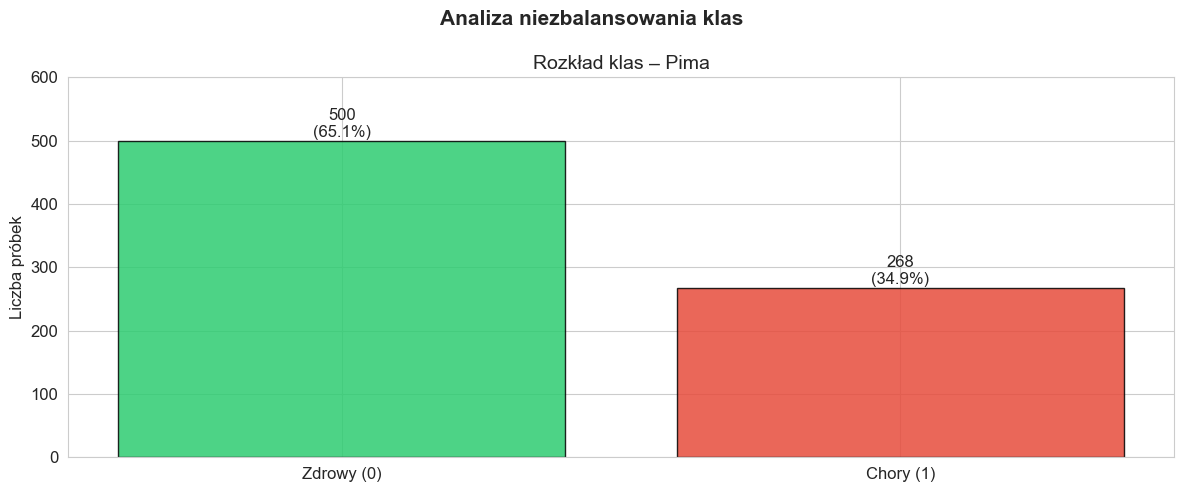


Wskaźnik niezbalansowania: 1.87:1
Uwaga: niezbalansowanie klas może wymagać technik takich jak SMOTE lub ważenie klas.


In [19]:
# Rozkład klas
class_counts = pima['Outcome'].value_counts()
class_pct    = pima['Outcome'].value_counts(normalize=True) * 100


fig, axes = plt.subplots(figsize=(12, 5))
#fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Wykres słupkowy
bars = axes.bar(['Zdrowy (0)', 'Chory (1)'], class_counts.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
for bar, cnt, pct in zip(bars, class_counts.values, class_pct.values):
    axes.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{cnt}\n({pct:.1f}%)', ha='center', fontsize=12)
axes.set_title('Rozkład klas – Pima', fontsize=14)
axes.set_ylabel('Liczba próbek')
axes.set_ylim(0, 600)

# Pie chart
#axes[1].pie(class_counts.values, labels=['Zdrowy (0)', 'Chory (1)'],
#            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
#            startangle=90, textprops={'fontsize': 12})
#axes[1].set_title('Proporcja klas – Pima', fontsize=14)

plt.suptitle('Analiza niezbalansowania klas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/class_distribution_pima.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nWskaźnik niezbalansowania: {class_counts[0]/class_counts[1]:.2f}:1')
print('Uwaga: niezbalansowanie klas może wymagać technik takich jak SMOTE lub ważenie klas.')

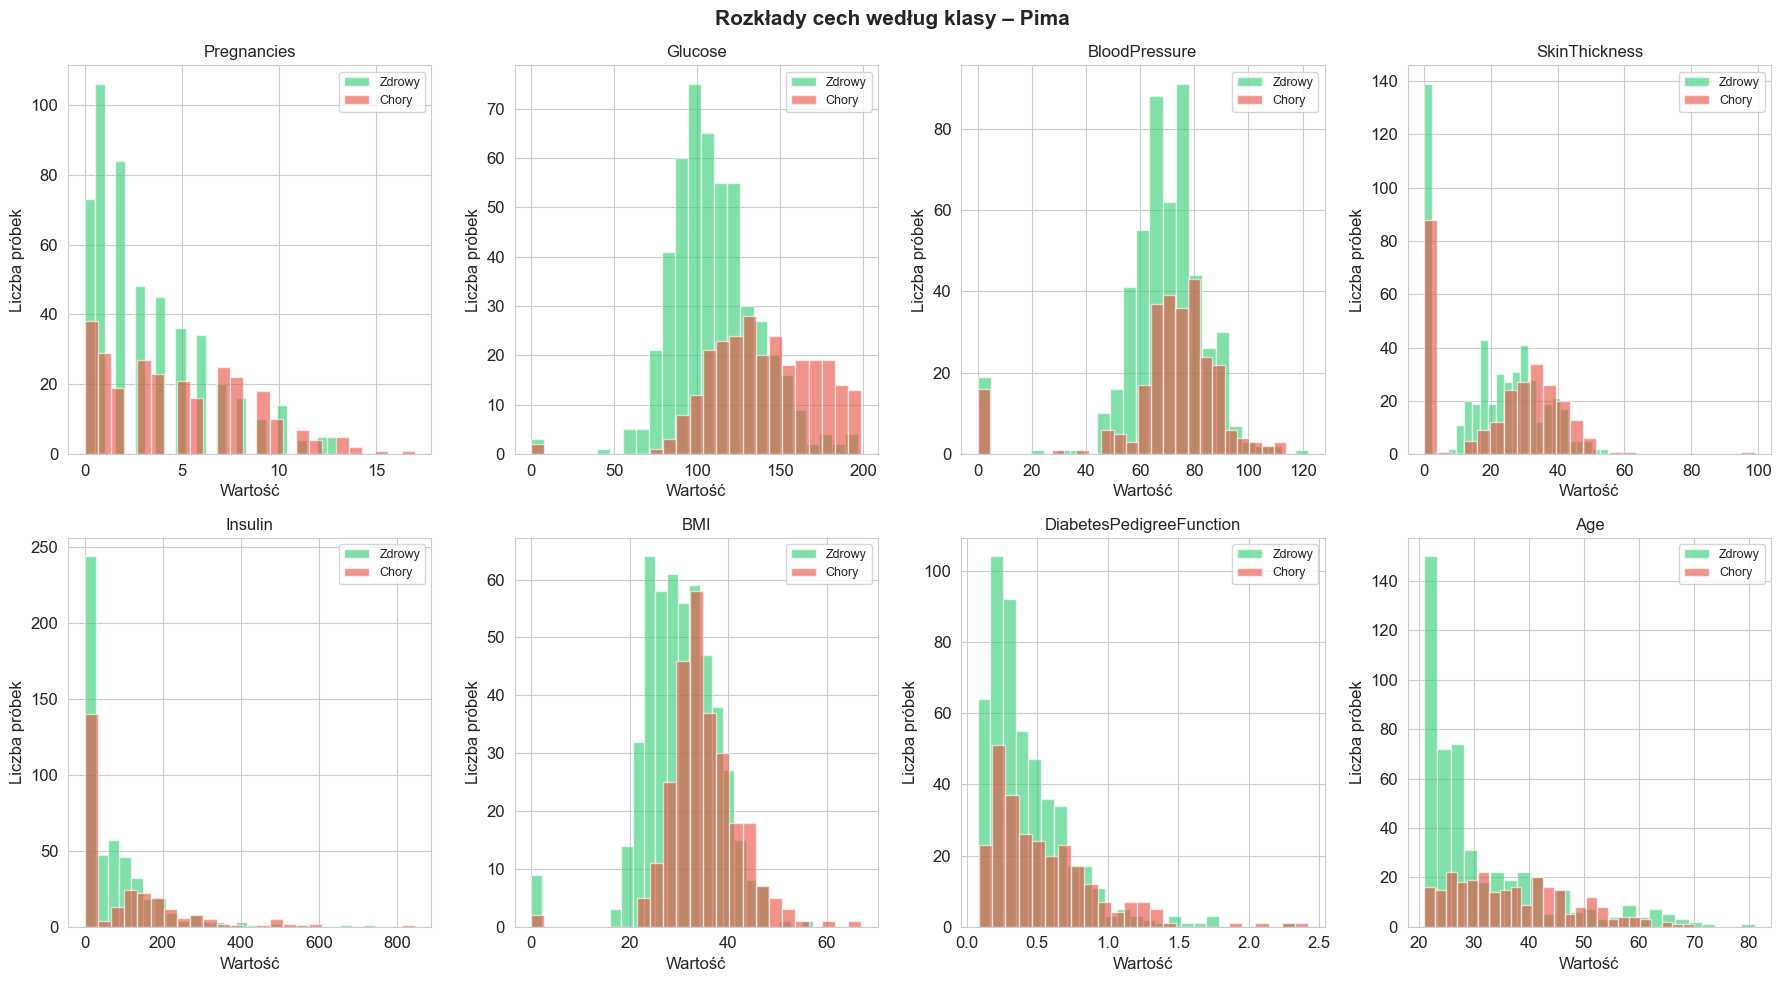

In [20]:
# Rozkłady wszystkich cech z podziałem na klasy
features = [c for c in pima.columns if c != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    for cls, color, label in [(0, '#2ecc71', 'Zdrowy'), (1, '#e74c3c', 'Chory')]:
        axes[i].hist(pima[pima['Outcome'] == cls][feat], bins=25,
                     alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(feat, fontsize=12)
    axes[i].set_xlabel('Wartość')
    axes[i].set_ylabel('Liczba próbek')
    axes[i].legend(fontsize=9)

plt.suptitle('Rozkłady cech według klasy – Pima', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_distributions_pima.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# === NHANES – selekcja istotnych klinicznie kolumn ===

# Budowanie zbioru NHANES z wybranymi predyktorami
nhanes_cols = {
    # Demograficzne
    'RIDAGEYR': 'Age',
    'RIAGENDR': 'Gender',
    'BMXBMI':   'BMI',
    # Ciśnienie krwi
    'BPXSY1':   'SystolicBP',
    'BPXDI1':   'DiastolicBP',
    # Badania laboratoryjne
    'LBXGH':    'HbA1c',
    'LBXSGL':   'Glucose',
    'LBXIN':    'Insulin',
    'LBXTR':    'Triglycerides',
    'LBDHDL':   'HDL',
    'LBDLDL':   'LDL',
    'LBXTC':    'TotalCholesterol',
    'LBXSCR':   'Creatinine',
}

# Zmienna docelowa z kwestionariusza (DIQ010: 1=Tak, 2=Nie)
# DIQ010: 'Doctor told you have diabetes'

nhanes_work = nhanes_master[
    [c for c in nhanes_cols.keys() if c in nhanes_master.columns] + ['DIQ010']
].copy()

# Zmiana nazw kolumn
rename_map = {k: v for k, v in nhanes_cols.items() if k in nhanes_work.columns}
nhanes_work = nhanes_work.rename(columns=rename_map)

# Tworzenie zmiennej docelowej: 1 = cukrzyca, 0 = brak
nhanes_work['Outcome'] = nhanes_work['DIQ010'].map({1.0: 1, 2.0: 0})
nhanes_work = nhanes_work.drop(columns=['DIQ010'])

# Filtrowanie tylko pełnoletnich (>=21 lat) by zachować spójność z Pima
nhanes_work = nhanes_work[nhanes_work['Age'] >= 21].copy()

# Usunięcie wierszy bez zdefiniowanej zmiennej docelowej
nhanes_work = nhanes_work[nhanes_work['Outcome'].notna()].copy()

print('='*60)
print('NHANES – PRZETWORZONY ZBIÓR DANYCH')
print('='*60)
print(f'Liczba próbek:  {nhanes_work.shape[0]}')
print(f'Liczba cech:    {nhanes_work.shape[1] - 1}  (+ Outcome)')
print()
print('Rozkład klas:')
print(nhanes_work['Outcome'].value_counts())
print(f'  → Prevalencja cukrzycy: {nhanes_work["Outcome"].mean()*100:.1f}%')
print()
print('Dostępne cechy:', list(nhanes_work.columns))

NHANES – PRZETWORZONY ZBIÓR DANYCH
Liczba próbek:  5311
Liczba cech:    12  (+ Outcome)

Rozkład klas:
Outcome
0.0    4605
1.0     706
Name: count, dtype: int64
  → Prevalencja cukrzycy: 13.3%

Dostępne cechy: ['Age', 'Gender', 'BMI', 'SystolicBP', 'DiastolicBP', 'HbA1c', 'Glucose', 'Insulin', 'Triglycerides', 'LDL', 'TotalCholesterol', 'Creatinine', 'Outcome']


In [22]:
print('Statystyki opisowe – NHANES (wybrane cechy):')
nhanes_work.describe().round(2)

Statystyki opisowe – NHANES (wybrane cechy):


,Age,Gender,BMI,SystolicBP,DiastolicBP,HbA1c,Glucose,Insulin,Triglycerides,LDL,TotalCholesterol,Creatinine,Outcome
count,5311.00,5311.00,5245.00,4861.00,4861.00,5130.00,5069.00,2394.00,2434.00,2397.00,5083.00,5069.00,5311.00
mean,49.44,1.52,29.09,123.17,70.05,5.74,105.00,13.20,120.84,111.17,189.53,0.92,0.13
std,17.21,0.50,7.10,18.20,12.74,1.08,41.79,20.06,126.11,35.11,41.95,0.54,0.34
min,21.00,1.00,14.10,66.00,0.00,3.50,49.00,0.14,14.00,14.00,69.00,0.30,0.00
25%,35.00,1.00,24.20,110.00,62.00,5.20,87.00,5.70,65.00,86.00,161.00,0.72,0.00
50%,48.00,2.00,27.80,120.00,70.00,5.50,95.00,9.00,95.00,108.00,187.00,0.86,0.00
75%,63.00,2.00,32.40,132.00,78.00,5.90,106.00,14.74,143.00,133.00,214.00,1.01,0.00
max,80.00,2.00,82.90,228.00,122.00,17.50,577.00,682.48,4233.00,375.00,813.00,17.41,1.00


---
## 3. Analiza korelacji cech

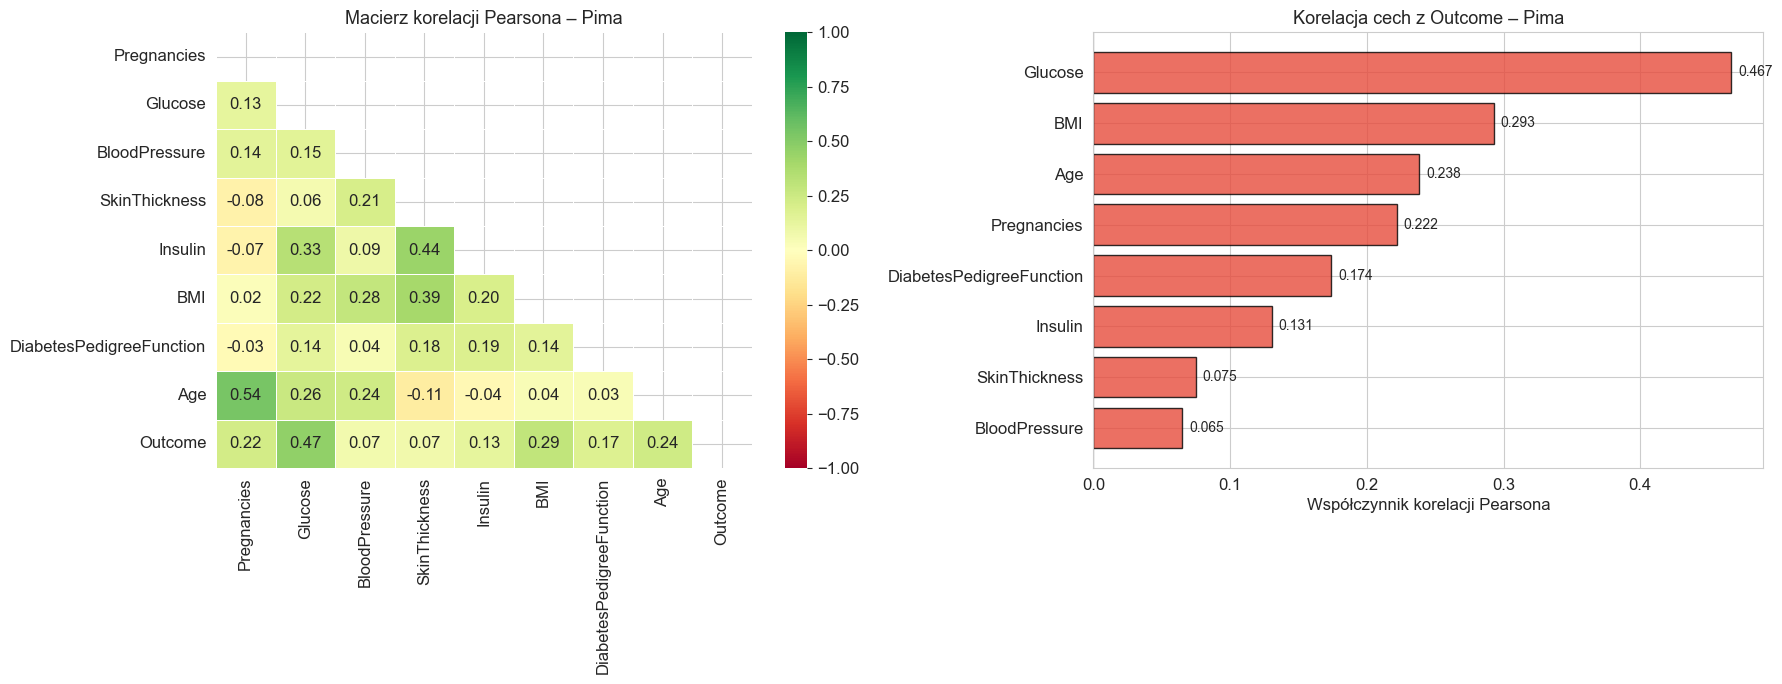


Najsilniejsze korelacje z Outcome (Pima):
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068


In [23]:
# === PIMA – macierz korelacji ===
corr_pima = pima.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmapa korelacji
mask = np.triu(np.ones_like(corr_pima, dtype=bool))
sns.heatmap(corr_pima, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Macierz korelacji Pearsona – Pima', fontsize=13)

# Korelacja z Outcome
corr_target = pima.corr()['Outcome'].drop('Outcome').sort_values()
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors, edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Korelacja cech z Outcome – Pima', fontsize=13)
axes[1].set_xlabel('Współczynnik korelacji Pearsona')
for i, v in enumerate(corr_target.values):
    axes[1].text(v + 0.005 if v >= 0 else v - 0.005, i,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig('plots/correlation_pima.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNajsilniejsze korelacje z Outcome (Pima):')
print(corr_target.abs().sort_values(ascending=False).to_string())

In [24]:
# Identyfikacja silnie skorelowanych par cech (potencjalne ryzyko metodologiczne)
print('Pary cech z |korelacja| > 0.5 (ryzyko współliniowości):')
print('-'*55)
features_only = pima.drop(columns=['Outcome'])
corr_matrix   = features_only.corr().abs()
upper_tri     = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(col, row, upper_tri.loc[row, col])
             for col in upper_tri.columns
             for row in upper_tri.index
             if pd.notna(upper_tri.loc[row, col]) and upper_tri.loc[row, col] > 0.5]

if high_corr:
    for c1, c2, val in sorted(high_corr, key=lambda x: -x[2]):
        print(f'  {c1:<30} ↔  {c2:<30}  r = {val:.3f}')
else:
    print('  Brak par cech z |r| > 0.5')

print('\nWniosek: Powyższe pary mogą powodować redundancję informacji.')
print('Selekcja cech (RFE, Mutual Information) pozwoli zidentyfikować najistotniejsze predyktory.')

Pary cech z |korelacja| > 0.5 (ryzyko współliniowości):
-------------------------------------------------------
  Age                            ↔  Pregnancies                     r = 0.544

Wniosek: Powyższe pary mogą powodować redundancję informacji.
Selekcja cech (RFE, Mutual Information) pozwoli zidentyfikować najistotniejsze predyktory.


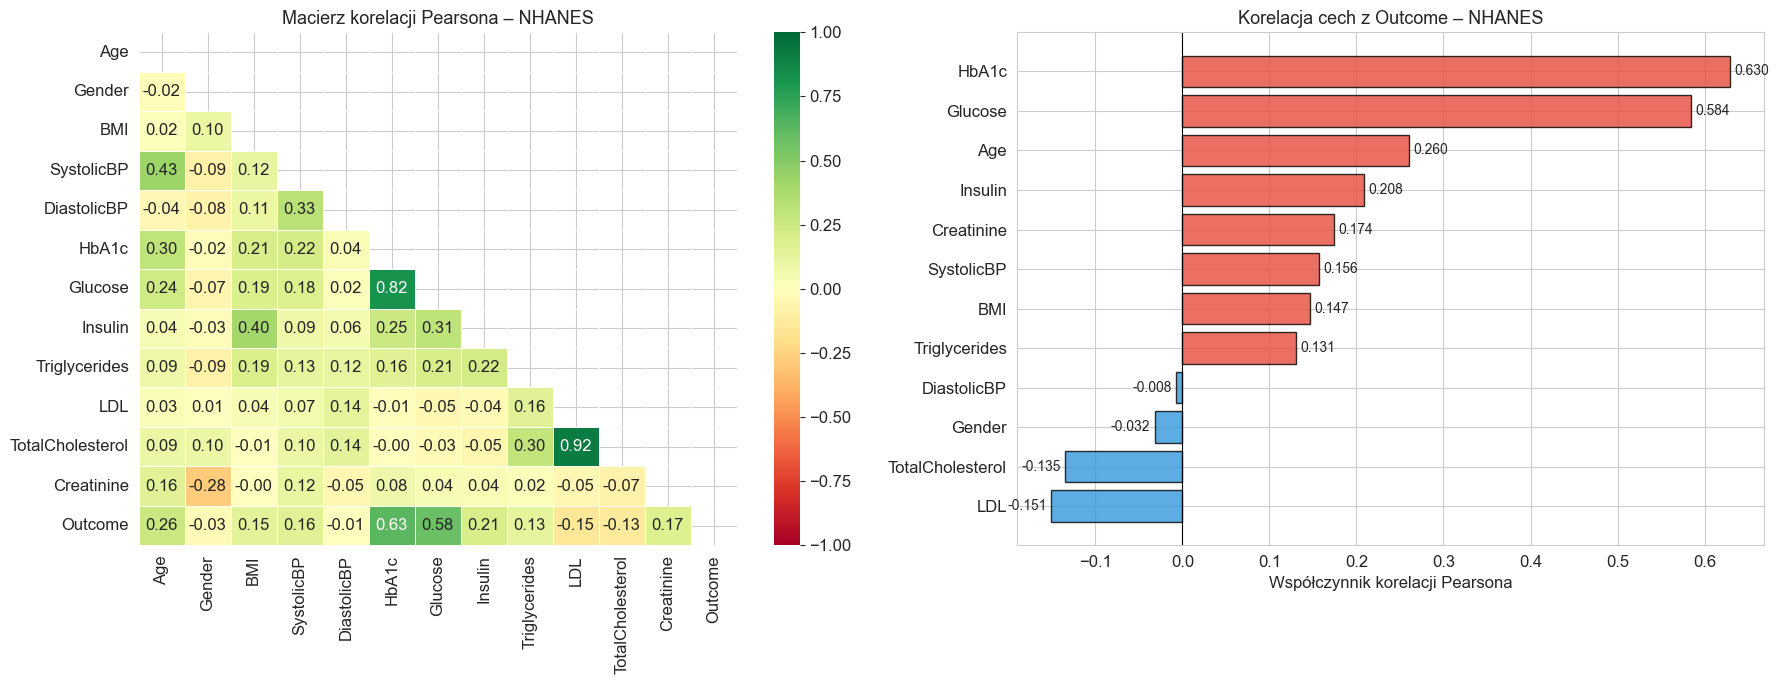


Najsilniejsze korelacje z Outcome (NHANES):
HbA1c               0.629575
Glucose             0.584338
Age                 0.259951
Insulin             0.208320
Creatinine          0.174467
SystolicBP          0.156456
LDL                 0.151158
BMI                 0.147013
TotalCholesterol    0.134736
Triglycerides       0.130852
Gender              0.031845
DiastolicBP         0.007540


In [25]:
# === NHANES – macierz korelacji ===
nhanes_num = nhanes_work.select_dtypes(include=[np.number]).dropna()
corr_nhanes = nhanes_num.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask_n = np.triu(np.ones_like(corr_nhanes, dtype=bool))
sns.heatmap(corr_nhanes, mask=mask_n, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Macierz korelacji Pearsona – NHANES', fontsize=13)

corr_target_n = corr_nhanes['Outcome'].drop('Outcome').sort_values()
colors_n = ['#e74c3c' if v > 0 else '#3498db' for v in corr_target_n.values]
axes[1].barh(corr_target_n.index, corr_target_n.values, color=colors_n, edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Korelacja cech z Outcome – NHANES', fontsize=13)
axes[1].set_xlabel('Współczynnik korelacji Pearsona')
for i, v in enumerate(corr_target_n.values):
    axes[1].text(v + 0.005 if v >= 0 else v - 0.005, i,
                 f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig('plots/correlation_nhanes.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nNajsilniejsze korelacje z Outcome (NHANES):')
print(corr_target_n.abs().sort_values(ascending=False).to_string())

---
## 4. Wstępna analiza braków danych

### 4.1 Ukryte braki w zbiorze Pima

Zbiór Pima nie zawiera jawnych wartości NaN, jednak kilka cech przyjmuje wartość **0**, która jest biologicznie niemożliwa. Są to de facto **zakodowane braki danych**, które należy przekształcić przed modelowaniem.

Braki danych po konwersji zer – Pima:
               Liczba braków  Procent braków (%)
Insulin                  374                48.7
SkinThickness            227                29.6
BloodPressure             35                 4.6
BMI                       11                 1.4
Glucose                    5                 0.7


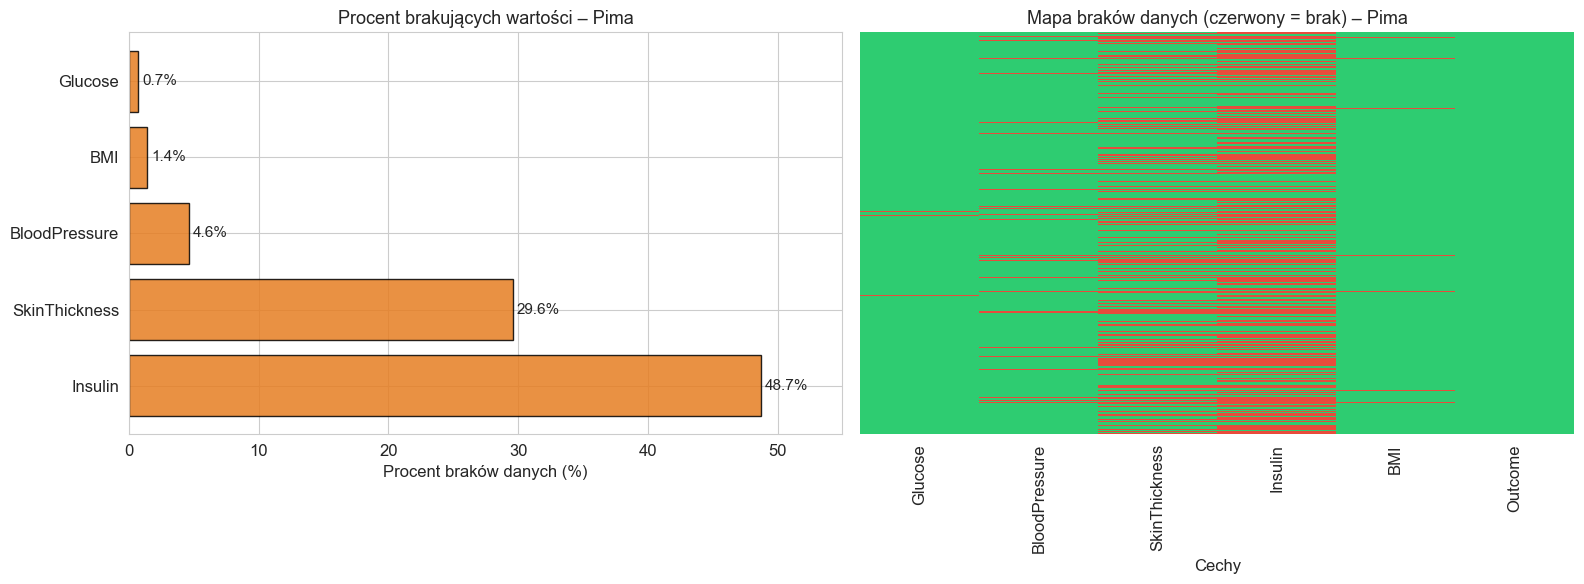

In [26]:
# Cechy, w których 0 oznacza brak danych (nie jest możliwa fizjologicznie)
zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

pima_missing = pima.copy()
pima_missing[zero_as_missing] = pima_missing[zero_as_missing].replace(0, np.nan)

# Analiza brakujących wartości
missing_counts = pima_missing.isnull().sum()
missing_pct    = (pima_missing.isnull().sum() / len(pima_missing)) * 100

missing_df = pd.DataFrame({
    'Liczba braków': missing_counts,
    'Procent braków (%)': missing_pct.round(1)
}).sort_values('Liczba braków', ascending=False)

print('Braki danych po konwersji zer – Pima:')
print(missing_df[missing_df['Liczba braków'] > 0].to_string())

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wykres słupkowy
missing_nonzero = missing_df[missing_df['Liczba braków'] > 0]
axes[0].barh(missing_nonzero.index, missing_nonzero['Procent braków (%)'],
             color='#e67e22', edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Procent braków danych (%)')
axes[0].set_title('Procent brakujących wartości – Pima', fontsize=13)
for i, v in enumerate(missing_nonzero['Procent braków (%)']):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=11)
axes[0].set_xlim(0, 55)

# Heatmapa obecności danych
sns.heatmap(pima_missing[zero_as_missing + ['Outcome']].isnull(),
            cbar=False, cmap=['#2ecc71', '#e74c3c'],
            yticklabels=False, ax=axes[1])
axes[1].set_title('Mapa braków danych (czerwony = brak) – Pima', fontsize=13)
axes[1].set_xlabel('Cechy')

plt.tight_layout()
plt.savefig('plots/missing_data_pima.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Analiza wzorców braków względem klasy docelowej
print('Procent braków wg klasy docelowej – Pima:')
print('-'*50)
for feat in zero_as_missing:
    m0 = pima_missing[pima_missing['Outcome']==0][feat].isnull().mean()*100
    m1 = pima_missing[pima_missing['Outcome']==1][feat].isnull().mean()*100
    print(f'  {feat:<25} Zdrowy: {m0:5.1f}%   Chory: {m1:5.1f}%')

print()
print('Strategia imputacji (do przetestowania w Raporcie 2):')
print('  1. Mean imputation   – prosta, zakłóca rozkład')
print('  2. Median imputation – odporna na wartości odstające')
print('  3. KNN imputation    – zachowuje lokalne zależności między cechami')

Procent braków wg klasy docelowej – Pima:
--------------------------------------------------
  Glucose                   Zdrowy:   0.6%   Chory:   0.7%
  BloodPressure             Zdrowy:   3.8%   Chory:   6.0%
  SkinThickness             Zdrowy:  27.8%   Chory:  32.8%
  Insulin                   Zdrowy:  47.2%   Chory:  51.5%
  BMI                       Zdrowy:   1.8%   Chory:   0.7%

Strategia imputacji (do przetestowania w Raporcie 2):
  1. Mean imputation   – prosta, zakłóca rozkład
  2. Median imputation – odporna na wartości odstające
  3. KNN imputation    – zachowuje lokalne zależności między cechami


Braki danych – NHANES (wybrane cechy):
                  Liczba braków  Procent braków (%)
Insulin                    2917                54.9
LDL                        2914                54.9
Triglycerides              2877                54.2
SystolicBP                  450                 8.5
DiastolicBP                 450                 8.5
Glucose                     242                 4.6
Creatinine                  242                 4.6
TotalCholesterol            228                 4.3
HbA1c                       181                 3.4
BMI                          66                 1.2
Age                           0                 0.0
Gender                        0                 0.0
Outcome                       0                 0.0


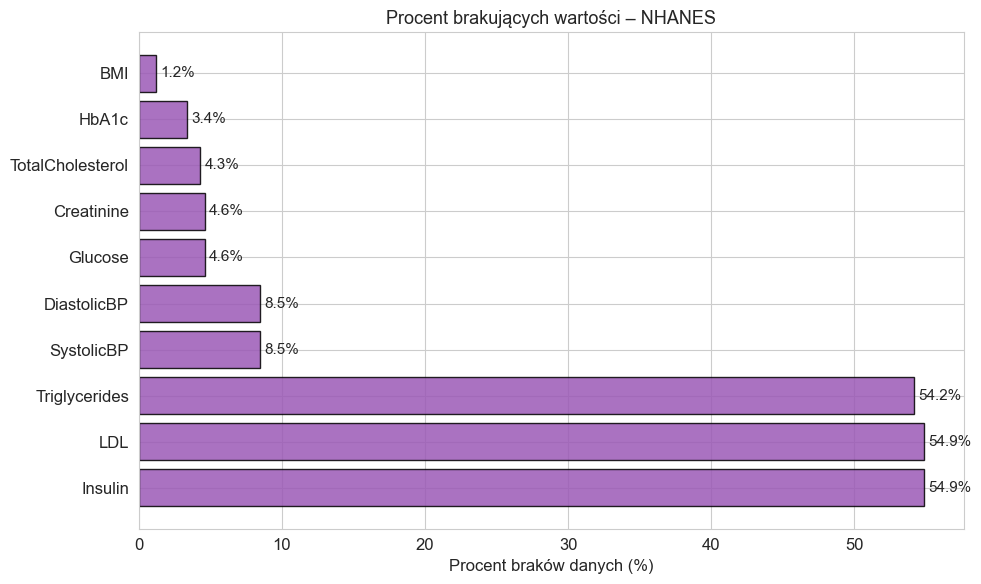

In [28]:
# === NHANES – analiza braków danych ===
nhanes_missing = nhanes_work.isnull().sum()
nhanes_missing_pct = (nhanes_missing / len(nhanes_work)) * 100

nhanes_missing_df = pd.DataFrame({
    'Liczba braków': nhanes_missing,
    'Procent braków (%)': nhanes_missing_pct.round(1)
}).sort_values('Liczba braków', ascending=False)

print('Braki danych – NHANES (wybrane cechy):')
print(nhanes_missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
nhanes_missing_nonzero = nhanes_missing_df[nhanes_missing_df['Liczba braków'] > 0]
ax.barh(nhanes_missing_nonzero.index, nhanes_missing_nonzero['Procent braków (%)'],
        color='#9b59b6', edgecolor='black', alpha=0.85)
ax.set_xlabel('Procent braków danych (%)')
ax.set_title('Procent brakujących wartości – NHANES', fontsize=13)
for i, v in enumerate(nhanes_missing_nonzero['Procent braków (%)']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('plots/missing_data_nhanes.png', dpi=150, bbox_inches='tight')
plt.show()

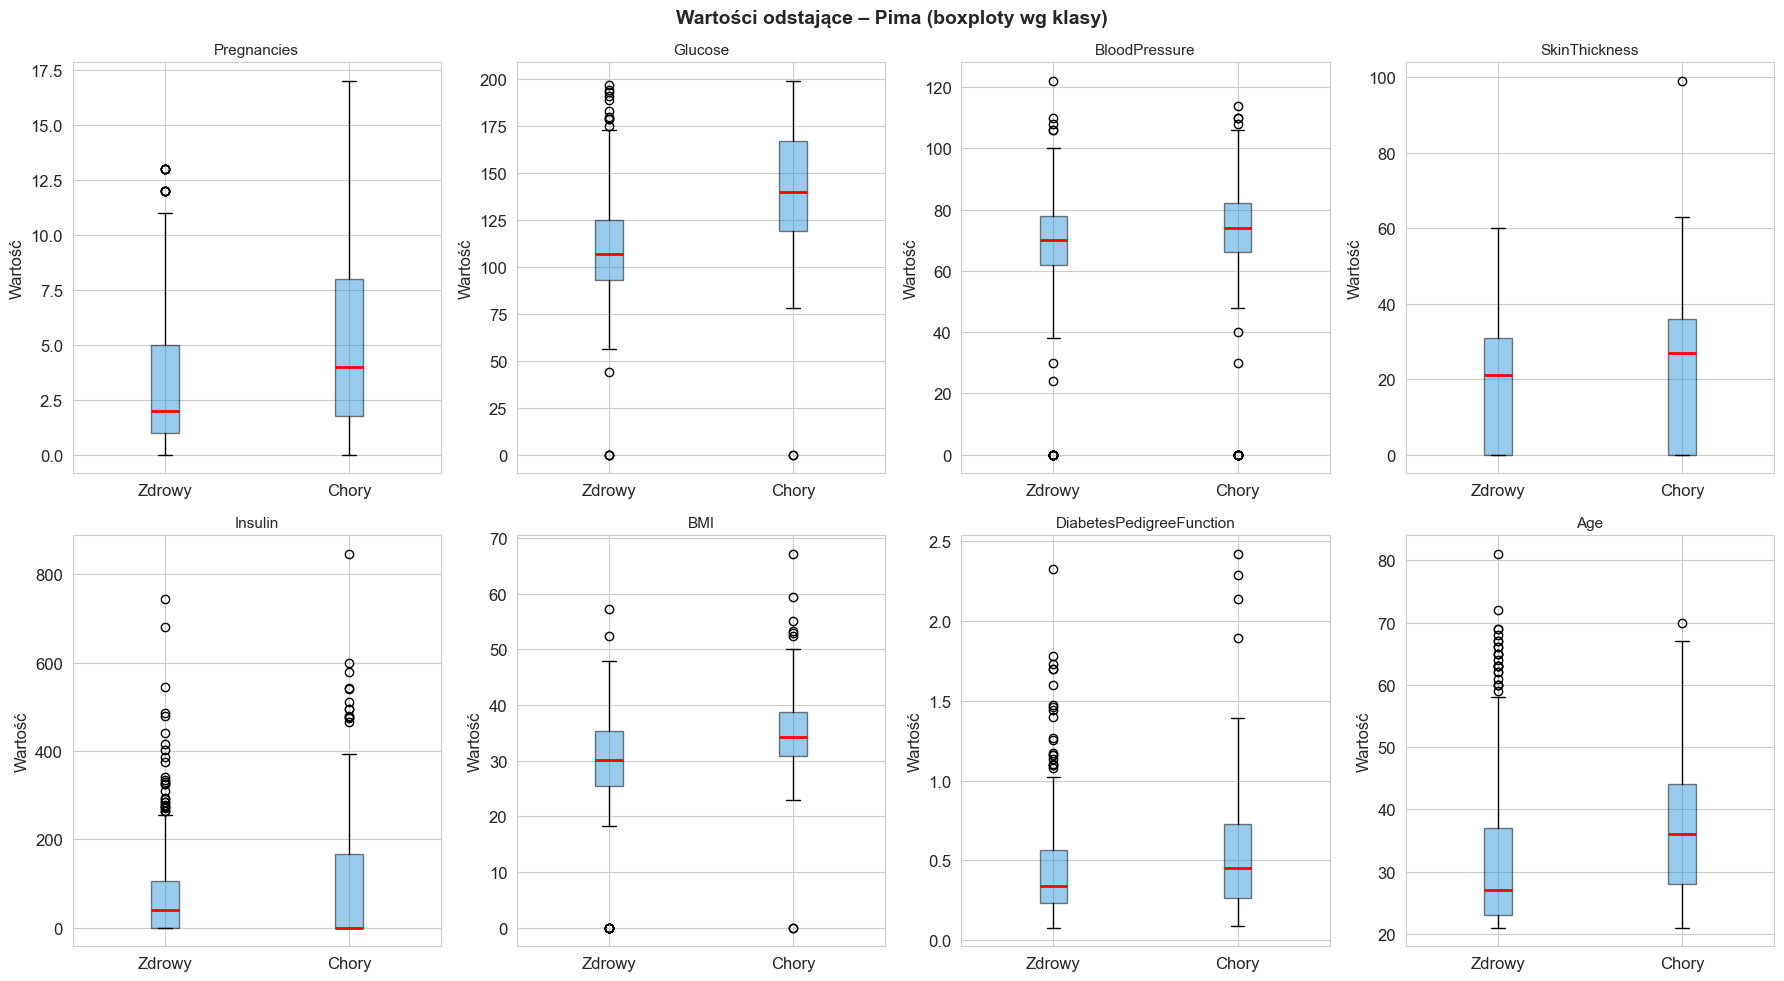

Liczba wartości odstających (metoda IQR) – Pima:
  Pregnancies                   :   4  (0.5%)
  Glucose                       :   5  (0.7%)
  BloodPressure                 :  45  (5.9%)
  SkinThickness                 :   1  (0.1%)
  Insulin                       :  34  (4.4%)
  BMI                           :  19  (2.5%)
  DiabetesPedigreeFunction      :  29  (3.8%)
  Age                           :   9  (1.2%)


In [29]:
# Analiza wartości odstających – boxploty
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    data_0 = pima[pima['Outcome']==0][feat]
    data_1 = pima[pima['Outcome']==1][feat]
    axes[i].boxplot([data_0, data_1], tick_labels=['Zdrowy', 'Chory'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.5),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_ylabel('Wartość')

plt.suptitle('Wartości odstające – Pima (boxploty wg klasy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/boxplots_pima.png', dpi=150, bbox_inches='tight')
plt.show()

# Liczba wartości odstających metodą IQR
print('Liczba wartości odstających (metoda IQR) – Pima:')
for feat in features:
    Q1, Q3 = pima[feat].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = ((pima[feat] < Q1 - 1.5*IQR) | (pima[feat] > Q3 + 1.5*IQR)).sum()
    print(f'  {feat:<30}: {outliers:3d}  ({outliers/len(pima)*100:.1f}%)')

---
## 5. Uzasadnienie wyboru modeli i metod analizy

### 5.1 Wybrane modele klasyfikacyjne

Zgodnie z wymaganiami projektu implementujemy minimum 3 modele, uwzględniając co najmniej 1 model liniowy, 1 nieliniowy i 1 zespołowy:

| Model | Typ | Uzasadnienie |
|---|---|---|
| **Logistic Regression** | Liniowy | Interpretowalny, dobry punkt odniesienia (baseline); dostarcza kalibrowanych prawdopodobieństw |
| **Support Vector Machine (RBF)** | Nieliniowy | Skuteczny przy danych klinicznych z nieliniowymi granicami klas; odporny na wymiarowość |
| **Random Forest** | Zespołowy | Naturalnie odporny na przeuczenie; dostarcza ważności cech; stabilny na CV |
| **Gradient Boosting** | Zespołowy | Wysoka jakość predykcji; analiza wpływu cech poprzez SHAP |

### 5.2 Metody selekcji cech

- **Mutual Information** – miara zależności statystycznej, działa dla relacji nieliniowych
- **Recursive Feature Elimination (RFE)** – iteracyjne usuwanie najmniej istotnych cech

### 5.3 Metody imputacji braków danych

- **Mean imputation** – zastępowanie wartością średniej (baseline)
- **Median imputation** – odporna na wartości odstające
- **KNN imputation** – zachowuje lokalne wzorce między cechami (k=5)

### 5.4 Metryki ewaluacyjne

- **Accuracy** – ogólna poprawność klasyfikacji
- **F1-score** – balans między precision a recall (istotny przy niezbalansowanych klasach)
- **ROC-AUC** – zdolność dyskryminacyjna modelu niezależna od progu decyzyjnego
- **Confusion matrix** – wizualizacja typów błędów (FP, FN)

### 5.5 Ryzyko metodologiczne – data leakage

W zbiorze NHANES istnieje ryzyko data leakage:
- HbA1c (LBXGH) jest samodzielnym kryterium diagnostycznym cukrzycy (HbA1c ≥ 6.5%) – model może "podglądać" diagnozę poprzez tę cechę
- Należy osobno zbadać wyniki modeli z i bez HbA1c oraz porównać je z wynikami opartymi wyłącznie na zmiennych niezwiązanych bezpośrednio z diagnozą

### 5.6 Podsumowanie hipotez badawczych

| Hipoteza | Oczekiwany efekt | Metoda weryfikacji |
|---|---|---|
| H1: Selekcja cech poprawia jakość | ↑ F1-score po RFE/MI | Porównanie przed/po selekcji |
| H2: Imputacja KNN > mean/median | ↑ Accuracy dla KNN | Eksperyment z 3 metodami imputacji |
| H3: RF stabilniejszy niż LR | ↓ std w k-CV dla RF | k-fold cross-validation (k=10) |

In [30]:
# === Podsumowanie Raportu 1 ===
print('='*65)
print('PODSUMOWANIE – RAPORT 1')
print('='*65)
print()
print('ZBIORY DANYCH:')
print(f'  Pima Indians Diabetes: {pima.shape[0]} próbek, {pima.shape[1]-1} cech')
print(f'  NHANES (przetworzone): {nhanes_work.shape[0]} próbek, {nhanes_work.shape[1]-1} cech')
print()
print('NIEZBALANSOWANIE KLAS:')
print(f'  Pima  – Zdrowy: {(pima["Outcome"]==0).sum()}  Chory: {(pima["Outcome"]==1).sum()}  ({pima["Outcome"].mean()*100:.1f}% chorych)')
nhanes_valid = nhanes_work[nhanes_work['Outcome'].notna()]
print(f'  NHANES – Zdrowy: {(nhanes_valid["Outcome"]==0).sum()}  Chory: {(nhanes_valid["Outcome"]==1).sum()}  ({nhanes_valid["Outcome"].mean()*100:.1f}% chorych)')
print()
print('BRAKI DANYCH (Pima – po konwersji zer):')
for feat in zero_as_missing:
    pct = pima_missing[feat].isnull().mean()*100
    if pct > 0:
        print(f'  {feat:<25}: {pct:.1f}%')
print()
print('NAJSILNIEJSZY PREDYKTOR (Pima):')
best = corr_target.abs().idxmax()
print(f'  {best}: r = {corr_target[best]:.3f}')
print()
print('ZAPLANOWANE MODELE:  Logistic Regression | SVM | Random Forest | Gradient Boosting')
print('SELEKCJA CECH:       Mutual Information | RFE')
print('IMPUTACJA:           Mean | Median | KNN')
print('WALIDACJA:           k-fold cross-validation (k=10)')

PODSUMOWANIE – RAPORT 1

ZBIORY DANYCH:
  Pima Indians Diabetes: 768 próbek, 8 cech
  NHANES (przetworzone): 5311 próbek, 12 cech

NIEZBALANSOWANIE KLAS:
  Pima  – Zdrowy: 500  Chory: 268  (34.9% chorych)
  NHANES – Zdrowy: 4605  Chory: 706  (13.3% chorych)

BRAKI DANYCH (Pima – po konwersji zer):
  Glucose                  : 0.7%
  BloodPressure            : 4.6%
  SkinThickness            : 29.6%
  Insulin                  : 48.7%
  BMI                      : 1.4%

NAJSILNIEJSZY PREDYKTOR (Pima):
  Glucose: r = 0.467

ZAPLANOWANE MODELE:  Logistic Regression | SVM | Random Forest | Gradient Boosting
SELEKCJA CECH:       Mutual Information | RFE
IMPUTACJA:           Mean | Median | KNN
WALIDACJA:           k-fold cross-validation (k=10)
